# Polynomial Linear Regrassion

**Goal:** Model a curved relationship between car price (`car_price`) and max speed (`max_speed`).

A straight line (linear regression) fits poorly here because speed gains plateau at high prices. Polynomial regression adds powers of `x` (e.g. `x²`, `x³`) so the model can bend to match the data.

### import libraries

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

### Import Data

In [2]:
df = pd.read_csv("polynomial-regression.csv",sep=";")


### Plot the Data

The scatter plot reveals a diminishing-returns curve: cheap cars become much faster as price rises, but beyond a certain price the speed improvement flattens. A straight line cannot capture this shape.

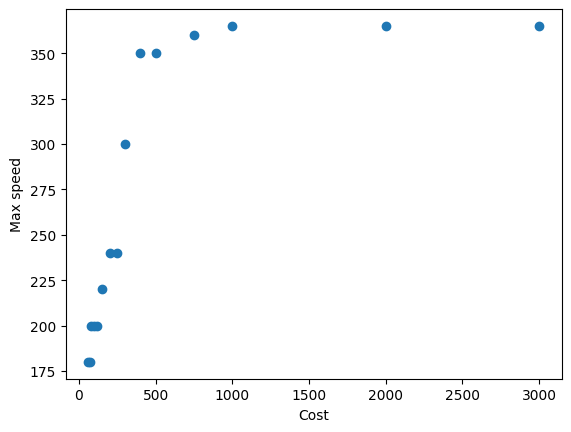

In [3]:
x = df.car_price.values.reshape(-1,1)
y = df.max_speed.values.reshape(-1,1)

plt.scatter(x,y)
plt.ylabel("Max speed")
plt.xlabel("Cost")
plt.show()

### Linear Regression Predict and visualization

The red line is the **linear regression** fit. It clearly misses the curve — it over-predicts low-priced cars and under-predicts mid-range ones.

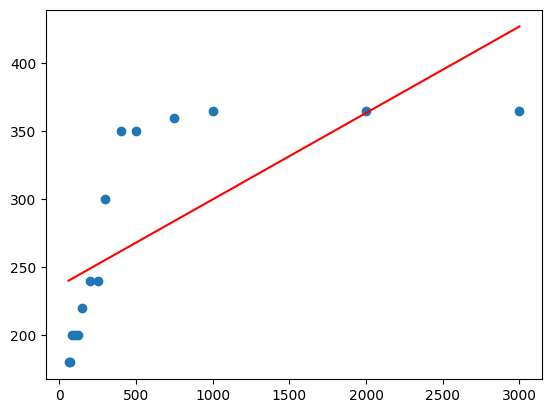

In [4]:
from sklearn.linear_model import LinearRegression 
lr = LinearRegression()
lr.fit(x,y)
y_head = lr.predict(x)
plt.plot(x,y_head,color="red")
plt.scatter(x,y)# as you can see the our linear regression line plot and it gives us high mean squared error values.
plt.show()      # and if we want to predict more accuracy, we have to change the regression model.

In [5]:
lr.predict([[10000]]) # there is no car that has 871 speed in this world thats why we have to change the regression to predict 
                      # more accuracy

array([[871.66401826]])

### Polynomial regression

`PolynomialFeatures(degree=4)` transforms `[x]` into `[1, x, x², x³, x⁴]`.  
We then feed this expanded feature matrix to a standard `LinearRegression` model.  
The model is still *linear in its coefficients* — only the features are raised to powers.

In [6]:
from sklearn.preprocessing import PolynomialFeatures
polynomial_regression = PolynomialFeatures(degree=4) # if we increase the degree, mean squared error is decreasing.Try 2 for degree
x_polynomial = polynomial_regression.fit_transform(x)

### Comparing between linear regression and polynomial regression  

The green curve (degree-4 polynomial) fits the data far better than the red line.  
⚠️ Choosing a very high degree can cause **overfitting** — always validate on unseen data.

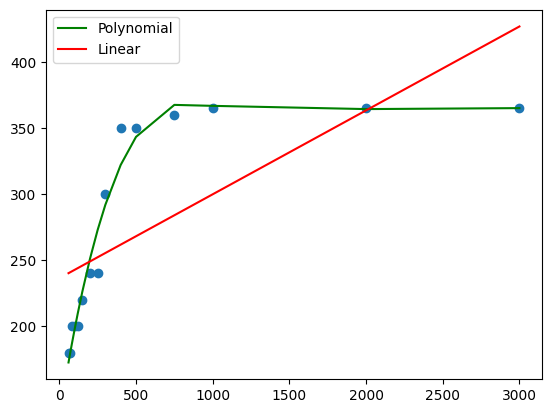

In [7]:
lr2 = LinearRegression()
lr2.fit(x_polynomial,y)
y_head2 = lr2.predict(x_polynomial)
plt.plot(x,y_head2,color="green",label="Polynomial")
plt.plot(x,y_head,color="red",label="Linear")
plt.scatter(x,y) # as you can see polynomial regression is better for this dataset to decrease mean squared error. 
plt.legend()     # and gives us better predicted values than linear regression 
plt.show()